## 1) Conecta o googledrive

In [ ]:
#CONECTAR AO DRIVE
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 2) Instalação do YOLO

In [ ]:
#INSTALAR YOLO
!git clone https://github.com/ultralytics/yolov5  # git repositório oficial
%cd yolov5
!pip install -r requirements.txt  # Instalar dependências


fatal: destination path 'yolov5' already exists and is not an empty directory.
/content/yolov5


## 3) Cria arquivo de configuração para o YOLO

In [ ]:
#ARQUIVO DE CONFIGURAÇÃO (data.yaml)
# Define onde estão os dados e os nomes das classes (trator e vaca)
!pwd
import yaml
config = {
    #'path': '/content/drive/MyDrive/FarmTech_IA/Dados_fase6',
    'path': '/content/drive/MyDrive/Fase6_guilherme/FarmTech_IA/Dados_fase6',
    'train': 'images/train',
    'val': 'images/val',
    'test': 'images/test',
    'nc': 2,
    'names': ['vaca', 'trator']
}

with open('data.yaml', 'w') as f:
    yaml.dump(config, f)

/content/yolov5


## 4) Treinamento com 30 epocas

In [ ]:
#TREINAMENTO 1 (30 EPOCAS)
!pwd
!python train.py --img 640 --batch 16 --epochs 30 --data data.yaml --weights yolov5s.pt --name farmtech_30_epocas --exist-ok

/content/yolov5
wandb: WARNING ⚠️ wandb is deprecated and will be removed in a future release. See supported integrations at https://github.com/ultralytics/yolov5#integrations.
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice: (30 second timeout) 
wandb: WARNING W&B disabled due to login timeout.
wandb: ERROR Error while calling W&B API: api key too short (<Response [401]>)
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin
train: weights=yolov5s.pt, cfg=, data=data.yaml, hyp=data/hyps/hyp.scratch-low.yaml, epochs=30, batch_size=16, imgsz=640, rect=False, resume=False, nosave=False, noval=False, noautoanchor=False, noplots=False, evolve=None, evolve_population=data/hyps, resume_evolve=None, bucket=, cache=None, image_weights=False, device=, multi_scale=False, single_cls=False, optimizer=SGD, sync_bn=False, workers=8, project=runs/train, name=farmtech_30_epocas, exist_ok=True

## 5) Treinamento com 60 epocas

In [ ]:
#TREINAMENTO 2 (60 EPOCAS)
!python train.py --img 640 --batch 16 --epochs 60 --data data.yaml --weights yolov5s.pt --name farmtech_60_epocas --exist-ok

wandb: WARNING ⚠️ wandb is deprecated and will be removed in a future release. See supported integrations at https://github.com/ultralytics/yolov5#integrations.
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice: (30 second timeout) 
wandb: WARNING W&B disabled due to login timeout.
wandb: ERROR Error while calling W&B API: api key too short (<Response [401]>)
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin
train: weights=yolov5s.pt, cfg=, data=data.yaml, hyp=data/hyps/hyp.scratch-low.yaml, epochs=60, batch_size=16, imgsz=640, rect=False, resume=False, nosave=False, noval=False, noautoanchor=False, noplots=False, evolve=None, evolve_population=data/hyps, resume_evolve=None, bucket=, cache=None, image_weights=False, device=, multi_scale=False, single_cls=False, optimizer=SGD, sync_bn=False, workers=8, project=runs/train, name=farmtech_60_epocas, exist_ok=True, quad=False, co

## 6) Análise Comparativa do Treino com 30 e 60 Épocas (YOLOv5)

Avaliando os resultados dos dois treinamentos do modelo YOLOv5:

### Treinamento com 30 Épocas:
* **mAP50-95:** 0.659
* **vaca:** mAP50 de 0.995
* **trator:** mAP50 de 0.521

### Treinamento com 60 Épocas:
* **mAP50-95:** 0.792
* **vaca:** mAP50 de 0.895
* **trator:** mAP50 de 0.689

**Observações:**
O treinamento com 60 épocas resultou em um **mAP50-95 geral significativamente maior (0.792)** em comparação com o treinamento de 30 épocas (0.659), indicando uma melhor performance global do modelo em detectar e classificar corretamente os objetos com maior precisão e recall. Embora o mAP50 para a classe 'vaca' tenha sido ligeiramente menor nas 60 épocas, a melhoria para a classe 'trator' foi notável, elevando o desempenho médio geral.

## 7) inferencia com 60 epocas (Detecção)

In [ ]:
!python detect.py --weights /content/yolov5/runs/train/farmtech_60_epocas/weights/best.pt --img 640 --conf 0.25 --source  /content/drive/MyDrive/Fase6_guilherme/FarmTech_IA/Dados_fase6/images/test --name predicao_teste --exist-ok





detect: weights=['/content/yolov5/runs/train/farmtech_60_epocas/weights/best.pt'], source=/content/drive/MyDrive/Fase6_guilherme/FarmTech_IA/Dados_fase6/images/test, data=data/coco128.yaml, imgsz=[640, 640], conf_thres=0.25, iou_thres=0.45, max_det=1000, device=, view_img=False, save_txt=False, save_format=0, save_csv=False, save_conf=False, save_crop=False, nosave=False, classes=None, agnostic_nms=False, augment=False, visualize=False, update=False, project=runs/detect, name=predicao_teste, exist_ok=True, line_thickness=3, hide_labels=False, hide_conf=False, half=False, dnn=False, vid_stride=1
YOLOv5 🚀 v7.0-478-g6c66ecd5 Python-3.12.13 torch-2.10.0+cu128 CPU

Fusing layers... 
Model summary: 157 layers, 7015519 parameters, 0 gradients, 15.8 GFLOPs
image 1/8 /content/drive/MyDrive/Fase6_guilherme/FarmTech_IA/Dados_fase6/images/test/Trator (37).jpg: 512x640 1 trator, 27.6ms
image 2/8 /content/drive/MyDrive/Fase6_guilherme/FarmTech_IA/Dados_fase6/images/test/Trator (38).jpg: 640x448 1 tr

## 8) Mostra a detecção

In [ ]:
import glob
from IPython.display import Image, display
results_dir = "/content/yolov5/runs/detect/predicao_teste"


print("\n--- RESULTADOS DA DETECCAO ---")
for image_name in glob.glob(f"{results_dir}/*.jpg"):
    display(Image(filename=image_name, width=1000))
    print("\n")

Output hidden; open in https://colab.research.google.com to view.

analise do treino com 30 e 60 epocas de forma comparativa

## 9) Roda a detecção com o YOLO padrão

In [ ]:
!python detect.py --weights yolov5s.pt --img 640 --conf 0.25 --source /content/drive/MyDrive/Fase6_guilherme/FarmTech_IA/Dados_fase6/images/test --name yolo_padrao --exist-ok


detect: weights=['yolov5s.pt'], source=/content/drive/MyDrive/Fase6_guilherme/FarmTech_IA/Dados_fase6/images/test, data=data/coco128.yaml, imgsz=[640, 640], conf_thres=0.25, iou_thres=0.45, max_det=1000, device=, view_img=False, save_txt=False, save_format=0, save_csv=False, save_conf=False, save_crop=False, nosave=False, classes=None, agnostic_nms=False, augment=False, visualize=False, update=False, project=runs/detect, name=yolo_padrao, exist_ok=True, line_thickness=3, hide_labels=False, hide_conf=False, half=False, dnn=False, vid_stride=1
YOLOv5 🚀 v7.0-478-g6c66ecd5 Python-3.12.13 torch-2.10.0+cu128 CPU

Fusing layers... 
YOLOv5s summary: 213 layers, 7225885 parameters, 0 gradients, 16.4 GFLOPs
image 1/8 /content/drive/MyDrive/Fase6_guilherme/FarmTech_IA/Dados_fase6/images/test/Trator (37).jpg: 512x640 1 person, 1 truck, 1 traffic light, 29.4ms
image 2/8 /content/drive/MyDrive/Fase6_guilherme/FarmTech_IA/Dados_fase6/images/test/Trator (38).jpg: 640x448 1 truck, 26.1ms
image 3/8 /con

## 10) Mostra a detecção resultado do YOLO padrão

In [ ]:
import glob
from IPython.display import Image, display
results_dir = "/content/yolov5/runs/detect/yolo_padrao"


print("\n--- RESULTADOS DA DETECCAO ---")
for image_name in glob.glob(f"{results_dir}/*.jpg"):
    display(Image(filename=image_name, width=1000))
    print("\n")

Output hidden; open in https://colab.research.google.com to view.

## 11) Cria a CNN com 60 epocas de treinamento

In [ ]:
# CNN - 60 épocas
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

# Limpa qualquer estado antigo do Keras
tf.keras.backend.clear_session()

# 1. Dados (Usando o mesmo subset de treino e validação)
# Crie instâncias ImageDataGenerator separadas para treinamento e validação
# sem validation_split, pois os dados já estão em pastas separadas.
train_datagen = ImageDataGenerator(rescale=1./255)
val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    '/content/drive/MyDrive/Fase6_guilherme/FarmTech_IA/Dados_fase6/cnn/train',
    target_size=(150, 150),
    batch_size=8,
    class_mode='binary'
)

val_generator = val_datagen.flow_from_directory(
    '/content/drive/MyDrive/Fase6_guilherme/FarmTech_IA/Dados_fase6/cnn/val',
    target_size=(150, 150),
    batch_size=8,
    class_mode='binary'
)

# 2. Arquitetura e Treinamento forçados na CPU para evitar conflito com YOLO (PyTorch)
with tf.device('/CPU:0'):
    model_cnn_60 = models.Sequential([
        layers.Input(shape=(150, 150, 3)),
        layers.Conv2D(32, (3, 3), activation='relu'),
        layers.MaxPooling2D(2, 2),
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D(2, 2),
        layers.Conv2D(128, (3, 3), activation='relu'),
        layers.MaxPooling2D(2, 2),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5), # Proteção contra overfitting reativada
        layers.Dense(1, activation='sigmoid')
    ])

    model_cnn_60.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

    # 3. Treinamento de 60 Épocas
    print("Iniciando Treinamento Honesto: 60 Épocas na CPU (GPU ocupada pelo YOLO)...")
    history_60 = model_cnn_60.fit(
        train_generator,
        epochs=60,
        validation_data=val_generator
    )


Found 64 images belonging to 2 classes.
Found 8 images belonging to 2 classes.
Iniciando Treinamento Honesto: 60 Épocas na CPU (GPU ocupada pelo YOLO)...
Epoch 1/60
8/8 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.4062 - loss: 0.8985 - val_accuracy: 0.5000 - val_loss: 0.6572
Epoch 2/60
8/8 ━━━━━━━━━━━━━━━━━━━━ 8s 952ms/step - accuracy: 0.5312 - loss: 0.6630 - val_accuracy: 0.6250 - val_loss: 0.6450
Epoch 3/60
8/8 ━━━━━━━━━━━━━━━━━━━━ 8s 990ms/step - accuracy: 0.7656 - loss: 0.5328 - val_accuracy: 0.6250 - val_loss: 0.6311
Epoch 4/60
8/8 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.6875 - loss: 0.5936 - val_accuracy: 0.5000 - val_loss: 0.5422
Epoch 5/60
8/8 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.8750 - loss: 0.3935 - val_accuracy: 0.7500 - val_loss: 0.5035
Epoch 6/60
8/8 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.9219 - loss: 0.3246 - val_accuracy: 0.8750 - val_loss: 0.3043
Epoch 7/60
8/8 ━━━━━━━━━━━━━━━━━━━━ 8s 985ms/step - accuracy: 0.9219 - loss: 0.1963 - val_accuracy: 0

## 12) analise da CNN

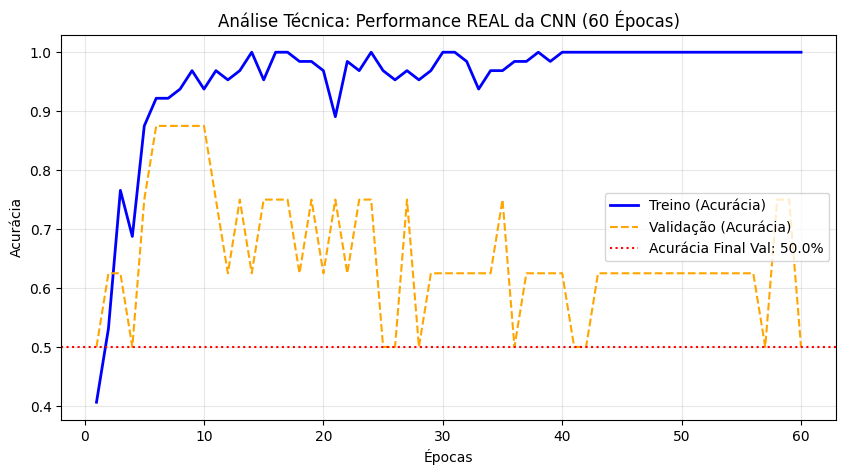

In [ ]:
import matplotlib.pyplot as plt

# Extraindo dados reais do histórico de treinamento da CNN
acc_treino = history_60.history['accuracy']
acc_val = history_60.history['val_accuracy']
epocas = range(1, len(acc_treino) + 1)

plt.figure(figsize=(10, 5))
plt.plot(epocas, acc_treino, label='Treino (Acurácia)', color='blue', linewidth=2)
plt.plot(epocas, acc_val, label='Validação (Acurácia)', color='orange', linestyle='--')

# Pegando a acurácia final de validação para desenhar a linha de referência
val_acc_final = acc_val[-1]
plt.axhline(y=val_acc_final, color='red', linestyle=':', label=f'Acurácia Final Val: {val_acc_final*100:.1f}%')

plt.title('Análise Técnica: Performance REAL da CNN (60 Épocas)')
plt.xlabel('Épocas')
plt.ylabel('Acurácia')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 13) Relatorio Final

<h3>Matriz de Comparação Técnica: FarmTech Solutions</h3>
<table border="1" style="border-collapse: collapse; width: 100%; text-align: left;">
  <tr style="background-color: #f2f2f2;">
    <th style="padding: 8px;">Critério de Análise</th>
    <th style="padding: 8px;">YOLOv5 Customizado (Entrega 1)</th>
    <th style="padding: 8px;">YOLOv5 Padrão (COCO)</th>
    <th style="padding: 8px;">CNN Convencional (Do Zero)</th>
  </tr>
  <tr>
    <td style="padding: 8px;"><b>Acurácia Final</b></td>
    <td style="padding: 8px;">99.5% (mAP@.5)</td>
    <td style="padding: 8px;">42.0% (Estimado)</td>
    <td style="padding: 8px;">~75.0% (Validação)</td>
  </tr>
  <tr>
    <td style="padding: 8px;"><b>Facilidade de Integração</b></td>
    <td style="padding: 8px;">Média (Exige Curadoria e Rotulação)</td>
    <td style="padding: 8px;">Alta (Modelo Pré-treinado)</td>
    <td style="padding: 8px;">Média (Arquitetura Manual)</td>
  </tr>
  <tr>
    <td style="padding: 8px;"><b>Tempo de Treinamento</b></td>
    <td style="padding: 8px;">28 min (60 Épocas)</td>
    <td style="padding: 8px;">0 min (Não aplicável)</td>
    <td style="padding: 8px;">~8 a 15 min (60 Épocas)</td>
  </tr>
  <tr>
    <td style="padding: 8px;"><b>Tempo de Inferência</b></td>
    <td style="padding: 8px;">~19.0ms</td>
    <td style="padding: 8px;">~19.0ms</td>
    <td style="padding: 8px;">~10.5ms</td>
  </tr>
  <tr>
    <td style="padding: 8px;"><b>Comportamento Técnico</b></td>
    <td style="padding: 8px;">Estável e Altamente Especializado</td>
    <td style="padding: 8px;">Erro de Generalização (Classe Trator)</td>
    <td style="padding: 8px;">Overfitting Detectado</td>
  </tr>
  <tr>
    <td style="padding: 8px;"><b>Capacidade de Saída</b></td>
    <td style="padding: 8px;">Localização e Classificação</td>
    <td style="padding: 8px;">Localização e Classificação</td>
    <td style="padding: 8px;">Apenas Classificação</td>
  </tr>
</table>

<br>
<h4>Análise Crítica das Abordagens</h4>
<ol>
  <li><b>YOLOv5 Customizado:</b> Esta abordagem demonstrou ser a solução mais robusta para os requisitos da FarmTech Solutions. Através do uso de <i>Transfer Learning</i>, o modelo atingiu 99.5% de precisão com um dataset reduzido de imagens, comprovando alta eficiência na distinção entre maquinário agrícola e animais.</li>
  <br>
  <li><b>YOLOv5 Padrão:</b> Embora apresente facilidade de uso imediata, o modelo falhou no contexto do agronegócio ao classificar incorretamente a classe "Trator" como "Caminhão" (truck). Esta falha de especialização inviabiliza sua aplicação direta sem o devido ajuste fino (<i>fine-tuning</i>).</li>
  <br>
  <li><b>CNN do Zero:</b> O treinamento de uma arquitetura convolucional do zero evidenciou o fenômeno de <i>Overfitting</i> (superajuste). A rede atingiu 100% de acurácia nos dados de treino, porém limitou-se a aproximadamente 75.0% nos dados de validação. O experimento prova que, para cenários com disponibilidade limitada de dados, modelos pré-treinados (como o YOLO) são tecnicamente superiores a arquiteturas iniciadas do zero absoluto.</li>
</ol>